In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner
from noise_generator import IndependentMarginals
from metrics import *
from random_graph import generate_random_graph, generate_random_tree
from chow_liu import chow_liu

# Graphs and Samples

In [4]:
rng = np.random.default_rng(seed=311)
random_graph = generate_random_graph(n=10, alphabet_size=2, n_factors=8, rng=rng)

rng = np.random.default_rng(seed=24)
random_tree = generate_random_tree(n=10, alphabet_size=2, rng=rng)

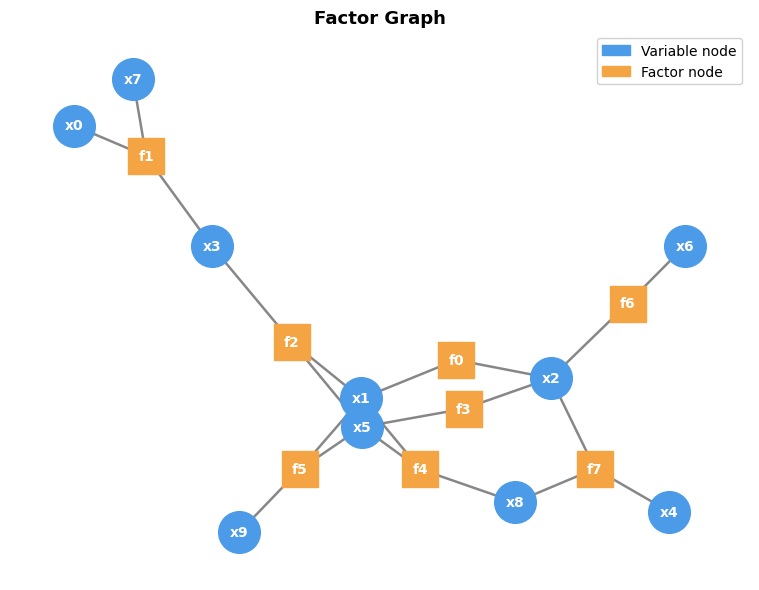

In [5]:
random_graph.display_graph(seed=388)
plt.show()

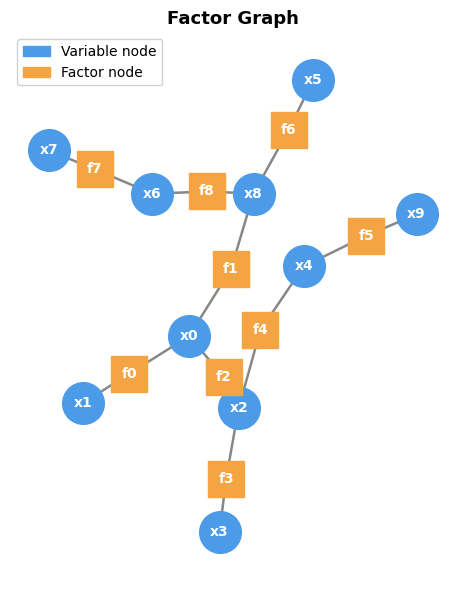

In [6]:
random_tree.display_graph(seed=72)
plt.show()

In [7]:
samples_graph = random_graph.sample(nsamples=500, seed=689)
samples_tree = random_tree.sample(nsamples=500, seed=920)

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 388.37it/s]


# Experiment

In [8]:
def one_learner(graph, samples, K, hidden_dims=(16,16), max_factor_size=None,
                shared_mlp=False, epochs=100, lr=0.01,
                l_mask=0.1, l_weight=0.01, l_mlp=0.01, l_bp=0.001,
                schedule=True, seed=123, verbose=True):

    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n

    ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)

    learner = FactorGraphLearner(
        n_vars=n_vars,
        alphabet_size=alph_size,
        K=K,
        noise_generator=ng,
        hidden_dims=hidden_dims,
        max_factor_size=max_factor_size,
        shared_mlp=shared_mlp,
        seed=seed
    )

    losses, diagnostics = learner.train(
        samples,
        n_epochs=epochs,
        lr=lr,
        lambda_mask=l_mask,
        lambda_weight=l_weight,
        lambda_mlp_l2=l_mlp,
        lambda_bp=l_bp,
        penalty_schedule=schedule,
        verbose=verbose
    )

    return learner, losses, diagnostics

In [9]:
def run_experiment(graph, samples, lambda_bp_vals, K,
                   hidden_dims=(16,16), max_factor_size=None,
                   shared_mlp=False, epochs=100, lr=0.01,
                   l_mask=1e-4, l_weight=1e-4, l_mlp=0.01,
                   schedule=True, seed=123, verbose=False, compute_kl=True):

    results = []

    for l_bp in tqdm(lambda_bp_vals):
        learner, losses, dgs = one_learner(
            graph, samples, K,
            hidden_dims=hidden_dims,
            max_factor_size=max_factor_size,
            shared_mlp=shared_mlp,
            epochs=epochs,
            lr=lr,
            l_mask=l_mask,
            l_weight=l_weight,
            l_mlp=l_mlp,
            l_bp=l_bp,
            schedule=schedule,
            seed=seed,
            verbose=verbose
        )

        results.append({
            "lambda_bp": l_bp,
            "nce_loss": losses["Main"][-1],
            "reg_loss": losses["Reg"][-1],
            "total_loss": losses["Total"][-1],
            "n_active_factors": dgs["n_active_factors"][-1],
            "avg_factor_size": dgs["avg_factor_size"][-1],
            "density": graph_density(learner),
            "SHD": structural_hamming_distance(graph, learner),
            "KL": kl_divergence(graph, learner) if compute_kl else None,
            "learner": learner  
        })

    return results

In [12]:
lambda_bp_vals = 10 ** np.arange(-3, -1+0.01, 0.025)

results_graph = run_experiment(
    random_graph, samples_graph, lambda_bp_vals,
    K=15, max_factor_size=5, seed=317
)

results_tree = run_experiment(
    random_tree, samples_tree, lambda_bp_vals,
    K=15, max_factor_size=5, seed=317
)

100%|███████████████████████████████████████████| 81/81 [05:32<00:00,  4.11s/it]


In [10]:
def plot_results(results, x, y):
    x_vec = np.array([r[x] for r in results])
    y_vec = np.array([r[y] for r in results])

    plt.scatter(x_vec, y_vec, alpha=0.7)
    plt.xscale("log")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [11]:
def plot_results_binned(results, x, y, nbins=10):
    x_vec = np.array([r[x] for r in results])
    y_vec = np.array([r[y] for r in results])

    idx = np.argsort(x_vec)
    x_sorted = x_vec[idx]
    y_sorted = y_vec[idx]

    n = len(results)

    mean_x, avg, sd = [], [], []

    for i in range(nbins):
        lo = int(n * i / nbins)
        hi = int(n * (i + 1) / nbins)

        x_bin = x_sorted[lo:hi]
        y_bin = y_sorted[lo:hi]

        mean_x.append(np.mean(x_bin))
        avg.append(np.mean(y_bin))
        sd.append(np.std(y_bin))

    plt.plot(mean_x, avg, marker="o")
    plt.xscale("log")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

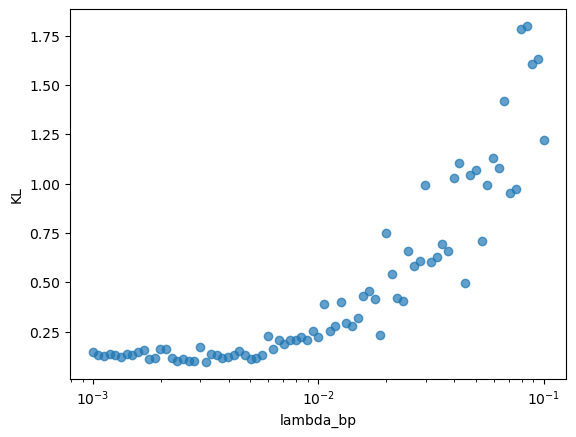

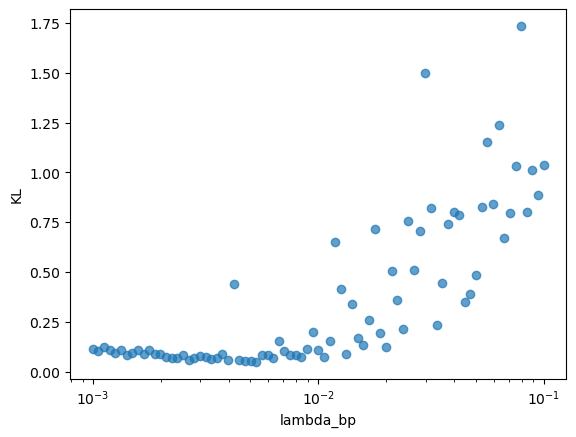

In [20]:
plot_results(results_graph, 'lambda_bp', 'KL')
plot_results(results_tree, 'lambda_bp', 'KL')

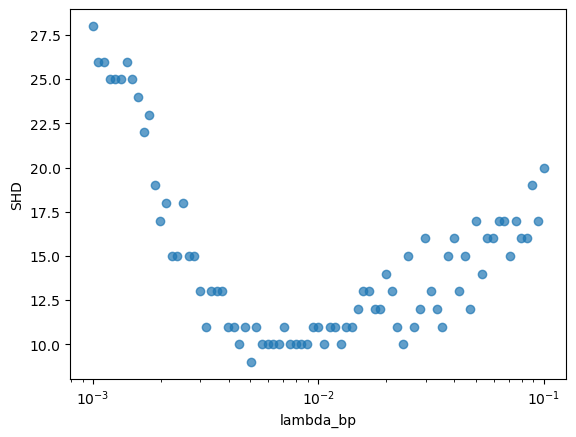

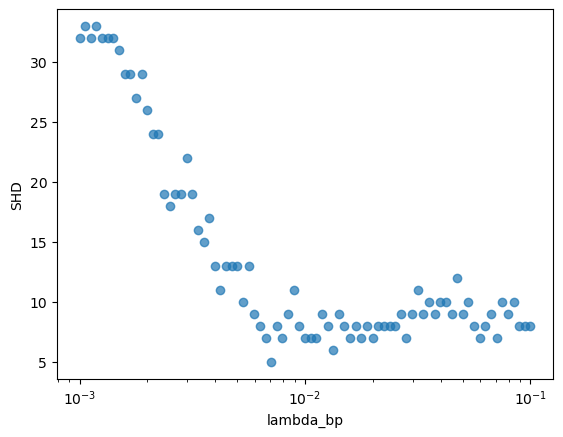

In [16]:
plot_results(results_graph, 'lambda_bp', 'SHD')
plot_results(results_tree, 'lambda_bp', 'SHD')

In [ ]:
plot_results(results_graph, 'lambda_bp', 'density')
plot_results(results_tree, 'lambda_bp', 'density')

# Recovered Graphs

In [12]:
best_lrn_graph, ls_graph, dg_graph = one_learner(random_graph, samples_graph, K=15, max_factor_size=5, 
                                                 l_mask=1e-4, l_weight=1e-4, l_bp=0.005, seed=317)
best_lrn_tree, ls_tree, gd_tree = one_learner(random_tree, samples_tree, K=15, max_factor_size=5,
                                              l_mask=1e-4, l_weight=1e-4, l_bp=0.005, seed=317)

Epoch   50/100  loss=0.5912  main=0.5547  reg=0.0365
Epoch  100/100  loss=0.5371  main=0.5239  reg=0.0133
Epoch   50/100  loss=0.6467  main=0.6107  reg=0.0359
Epoch  100/100  loss=0.6274  main=0.6141  reg=0.0133


In [13]:
best_res_graph = {
    'n_active_factors' : best_lrn_graph.network.n_active_factors().item(),
    'avg_factor_size' : best_lrn_graph.network.avg_factor_size().item(),
    'density' : graph_density(best_lrn_graph),
    'SHD' : structural_hamming_distance(random_graph, best_lrn_graph),
    'KL' : kl_divergence(random_graph, best_lrn_graph)
}

best_res_tree = {
    'n_active_factors' : best_lrn_tree.network.n_active_factors().item(),
    'avg_factor_size' : best_lrn_tree.network.avg_factor_size().item(),
    'density' : graph_density(best_lrn_tree),
    'SHD' : structural_hamming_distance(random_tree, best_lrn_tree),
    'KL' : kl_divergence(random_tree, best_lrn_tree)
}

In [14]:
compare_graph(random_graph, best_lrn_graph)

=== GRAPH 1 FACTORS ===
[1, 2]
[0, 3, 7]
[1, 3, 5]
[2, 5]
[1, 5, 8]
[1, 5, 9]
[2, 6]
[2, 4, 8]

=== GRAPH 2 FACTORS ===
[1, 3, 5, 9]
[0, 7]
[0, 1]
[1, 5]
[1, 2]
[2, 5, 9]
[3, 5]
[2, 4, 8]
[7]
[6, 8]


In [15]:
compare_graph(random_tree, best_lrn_tree)

=== GRAPH 1 FACTORS ===
[0, 1]
[0, 8]
[0, 2]
[2, 3]
[2, 4]
[4, 9]
[5, 8]
[6, 7]
[6, 8]

=== GRAPH 2 FACTORS ===
[0, 2, 3, 8]
[6, 7]
[0, 6, 8]
[0]
[5, 7, 8]
[2, 3, 4, 9]
[3, 7]
[0, 1]
[5, 8]


In [16]:
kl_mle_optimal(random_graph, samples_graph)

0.37322691928488594

In [17]:
chow_liu_graph = chow_liu(samples_graph, alphabet_size=2)
chow_liu_res_graph = {
    'n_active_factors' : len(chow_liu_graph.factors),
    'avg_factor_size' : np.mean([len(sc) for sc, f in chow_liu_graph.factors]),
    'density' : graph_density(chow_liu_graph),
    'SHD' : structural_hamming_distance(random_graph, chow_liu_graph),
    'KL' : kl_divergence(random_graph, chow_liu_graph)
}

chow_liu_tree = chow_liu(samples_tree, alphabet_size=2)
chow_liu_res_tree = {
    'n_active_factors' : len(chow_liu_tree.factors),
    'avg_factor_size' : np.mean([len(sc) for sc, f in chow_liu_tree.factors]),
    'density' : graph_density(chow_liu_tree),
    'SHD' : structural_hamming_distance(random_tree, chow_liu_tree),
    'KL' : kl_divergence(random_tree, chow_liu_tree)
}

In [18]:
chow_liu_res_graph, best_res_graph

({'n_active_factors': 10,
  'avg_factor_size': 1.9,
  'density': 1.0,
  'SHD': 9,
  'KL': 0.13101763802609706},
 {'n_active_factors': 10,
  'avg_factor_size': 2.299999952316284,
  'density': 1.6666666666666667,
  'SHD': 9,
  'KL': 0.13558081551490733})

In [19]:
chow_liu_res_tree, best_res_tree

({'n_active_factors': 10,
  'avg_factor_size': 1.9,
  'density': 1.0,
  'SHD': 0,
  'KL': 0.012789733215894338},
 {'n_active_factors': 9,
  'avg_factor_size': 2.555555582046509,
  'density': 2.111111111111111,
  'SHD': 10,
  'KL': 0.03775957700803285})

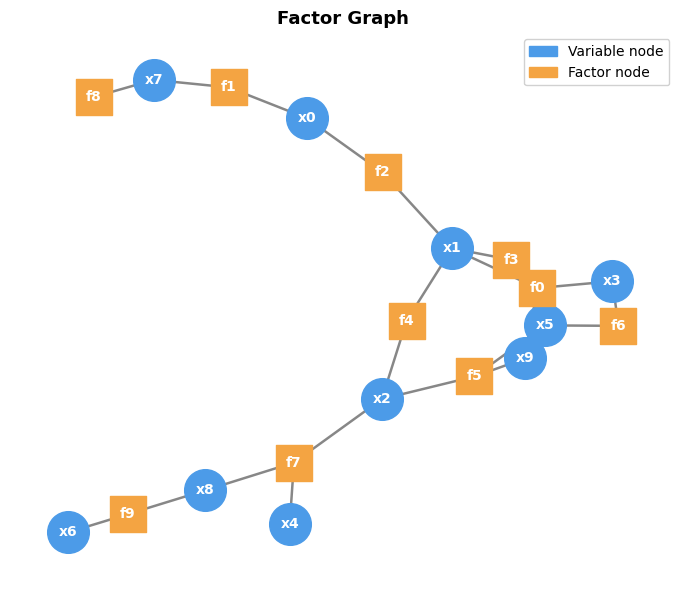

In [20]:
def learner_to_graph(lrn):
    fscopes = lrn.extract_graph()['factor_scopes']
    def h(): return 1
    factors = [(f, h) for f in fscopes.values()]
    g = TrueGraph(n=lrn.network.n_vars, factors=factors)
    return g

learner_to_graph(best_lrn_graph).display_graph(seed=38)
plt.show()

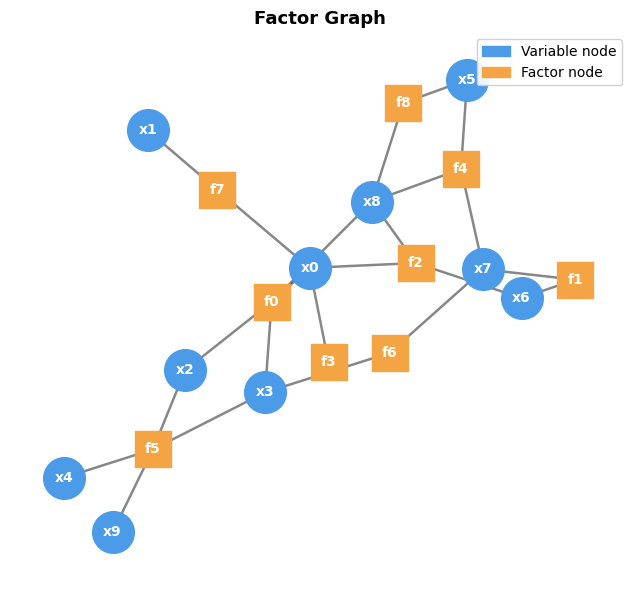

In [21]:
learner_to_graph(best_lrn_tree).display_graph(seed=34)
plt.show()

In [22]:
kl_mle_optimal(random_tree, samples_tree)

0.40577652351832594

# Reg vs Sample Size

In [36]:
mega_samples_graph = random_graph.sample(nsamples=10000, seed=689)

100%|████████████████████████████████████| 10000/10000 [00:27<00:00, 365.52it/s]


In [40]:
sample_sizes = [100,500,1000,5000,10000]
ss_results = {}

ss_lambda_bp_vals = 10**np.arange(-3,-1+0.01,0.25)

for ss in sample_sizes:
    samples_here = mega_samples_graph[:ss,]
    exp_results = run_experiment(
        random_graph, samples_here, ss_lambda_bp_vals,
        K=15, max_factor_size=5, epochs=80, seed=317
    )
    ss_results[ss] = exp_results

100%|█████████████████████████████████████████████| 9/9 [09:48<00:00, 65.38s/it]


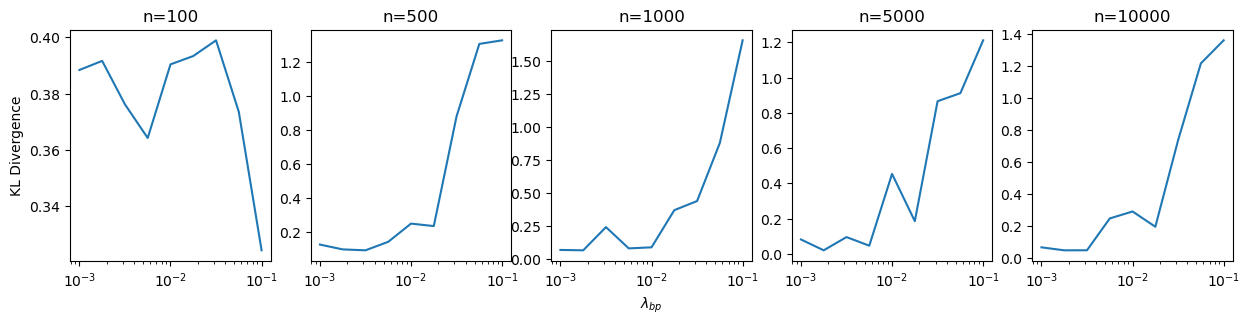

In [52]:
# KL plot
fig, axs = plt.subplots(1,5, figsize=(15,3))
for i in range(len(sample_sizes)):
    ss = sample_sizes[i]
    res = ss_results[ss]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['KL'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n={ss}")
    if i == 0:
        axs[i].set_ylabel("KL Divergence")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

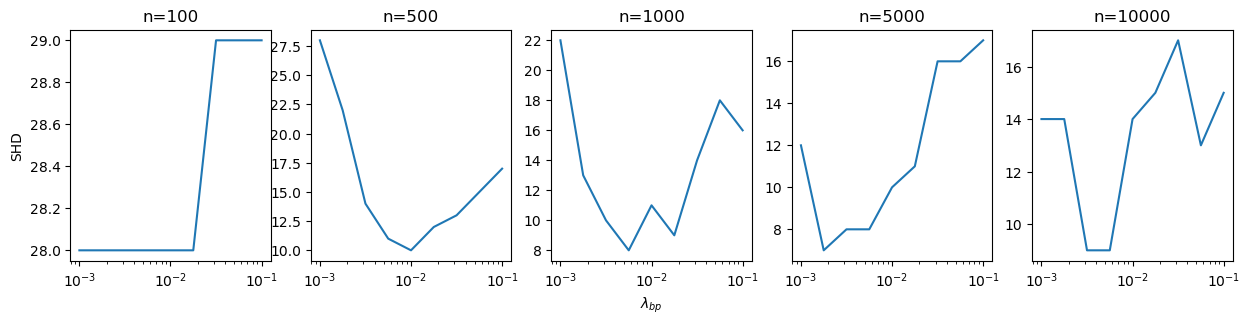

In [53]:
# SHD plot
fig, axs = plt.subplots(1,5, figsize=(15,3))
for i in range(len(sample_sizes)):
    ss = sample_sizes[i]
    res = ss_results[ss]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['SHD'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n={ss}")
    if i == 0:
        axs[i].set_ylabel("SHD")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

# Reg vs Graph Size

In [64]:
n_vars_list = np.arange(5,31,5,dtype=np.int32)

size_results = {}

size_lambda_bp_vals = 10**np.arange(-3,-1+0.01,0.25)

for size in n_vars_list:
    rng = np.random.default_rng(123)
    graph_here = generate_random_tree(n=size, alphabet_size=2, rng=rng)
    samples_here = graph_here.sample(nsamples=500, seed=50, progress=False)
    exp_results = run_experiment(
        graph_here, samples_here, size_lambda_bp_vals,
        K=int(1.5*size), max_factor_size=5, epochs=80, seed=317, compute_kl=False
    )
    size_results[size] = exp_results

100%|█████████████████████████████████████████████| 9/9 [01:21<00:00,  9.05s/it]


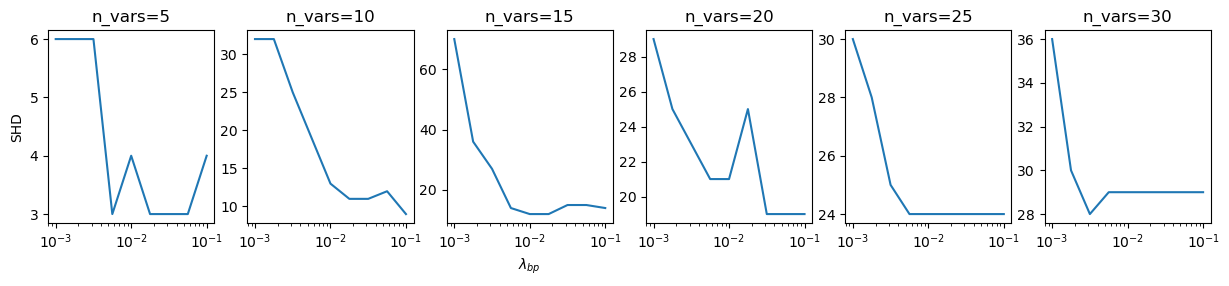

In [69]:
# SHD plot
fig, axs = plt.subplots(1,6, figsize=(15,2.5))
for i in range(len(n_vars_list)):
    nv = n_vars_list[i]
    res = size_results[nv]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['SHD'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n_vars={nv}")
    if i == 0:
        axs[i].set_ylabel("SHD")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

# Final Visualizations

In [23]:
mle_kl_graph = kl_mle_optimal(random_graph, samples_graph)
mle_kl_tree = kl_mle_optimal(random_tree, samples_tree)

NameError: name 'results_graph' is not defined

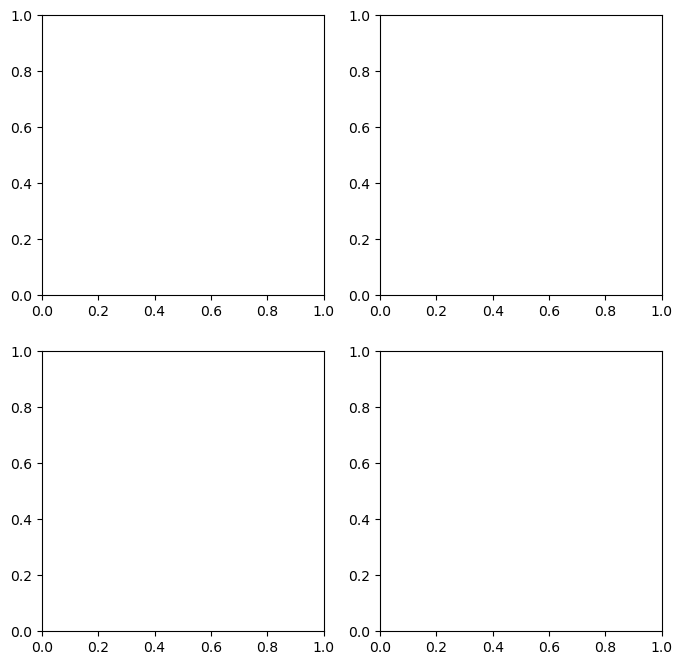

In [24]:
fig, axs = plt.subplots(2,2, figsize=(8,8))

x_gr = [r['lambda_bp'] for r in results_graph]
x_tr = [r['lambda_bp'] for r in results_tree]
y_gr_kl = [r['KL'] for r in results_graph]
y_gr_shd = [r['SHD'] for r in results_graph]
y_tr_kl = [r['KL'] for r in results_tree]
y_tr_shd = [r['SHD'] for r in results_tree]

axs[0,0].scatter(x_gr, y_gr_kl, alpha=0.7)
axs[0,0].axhline(y=mle_kl_graph, color='r', linestyle='--')
axs[0,0].annotate("MLE KL", (10**-2.8,0.4), color='r')
axs[0,0].set_xscale('log')
axs[0,0].set_ylabel("KL Divergence")
axs[0,0].set_title("Loopy Graph")

axs[0,1].scatter(x_tr, y_tr_kl, alpha=0.7)
axs[0,1].axhline(y=mle_kl_tree, color='r', linestyle='--')
axs[0,1].annotate("MLE KL", (10**-2.8,0.45), color='r')
axs[0,1].set_xscale('log')
axs[0,1].set_title("Tree")

axs[1,0].scatter(x_gr, y_gr_shd, alpha=0.7)
axs[1,0].set_xscale('log')
axs[1,0].set_ylabel("SHD")
axs[1,0].set_xlabel("$\lambda_{bp}$")

axs[1,1].scatter(x_tr, y_tr_shd, alpha=0.7)
axs[1,1].set_xscale('log')
axs[1,1].set_xlabel("$\lambda_{bp}$")

# plt.savefig('../img/reg_fig.png')
plt.show()

In [23]:
lrn_high_reg, _, _ = one_learner(random_graph, samples_graph, K=15, max_factor_size=5, 
                                 l_mask=1e-4, l_weight=1e-4, l_bp=0.05, seed=317)
lrn_low_reg, _, _ = one_learner(random_graph, samples_graph, K=15, max_factor_size=5, 
                                l_mask=1e-4, l_weight=1e-4, l_bp=0.0005, seed=317)

Epoch   50/100  loss=0.8701  main=0.7558  reg=0.1144
Epoch  100/100  loss=0.8265  main=0.7874  reg=0.0391
Epoch   50/100  loss=0.5514  main=0.5368  reg=0.0146
Epoch  100/100  loss=0.4997  main=0.4931  reg=0.0066


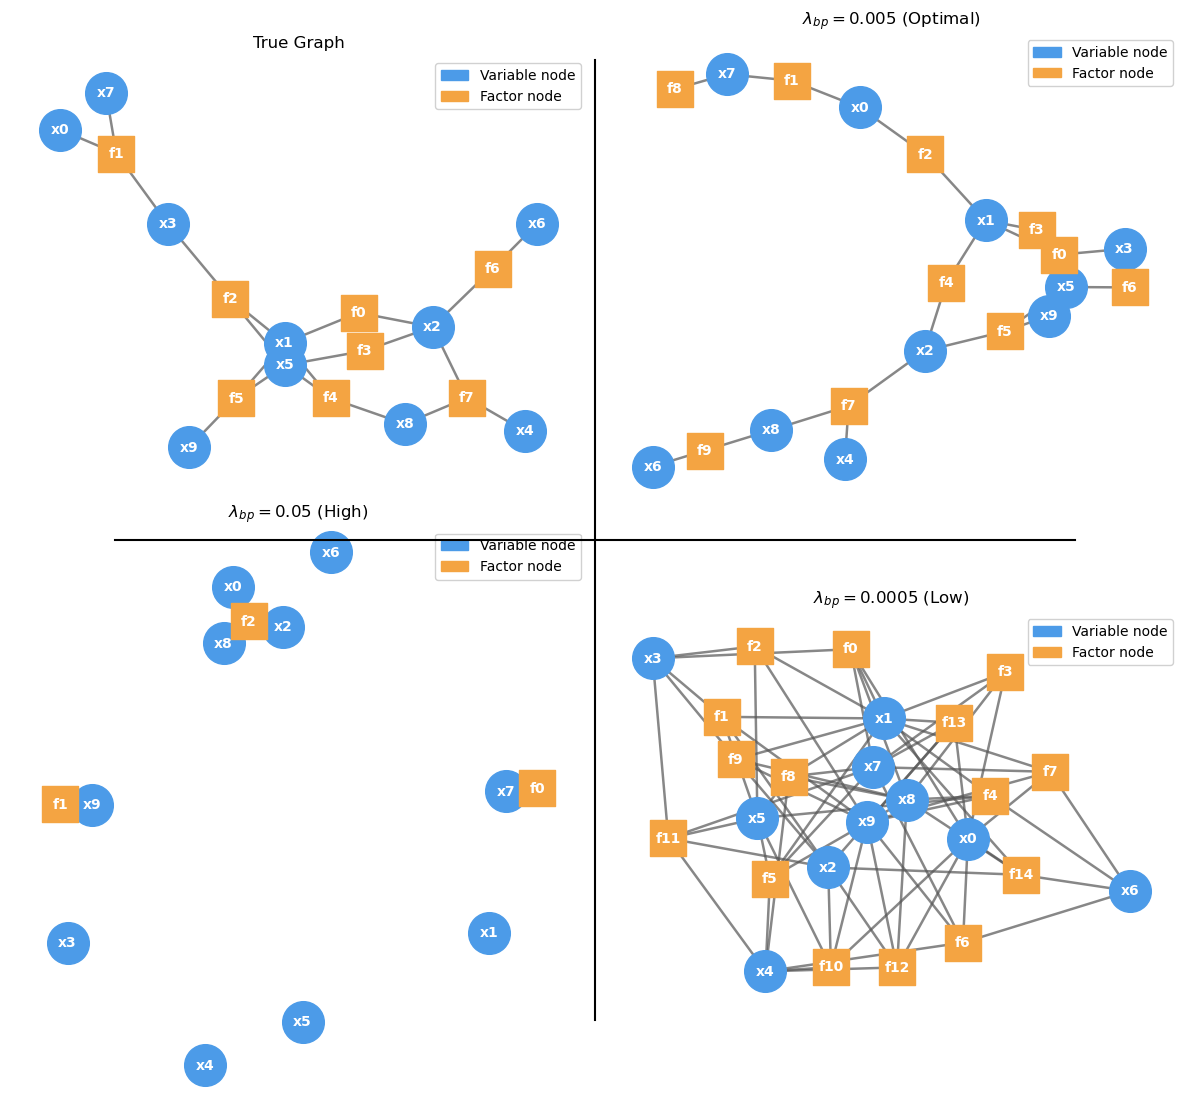

In [38]:
fig, axs = plt.subplots(2,2, figsize=(12,12))

import matplotlib.lines as lines
line1 = lines.Line2D([0.5, 0.5], [0.1, 0.9], transform=fig.transFigure, color='black')
line2 = lines.Line2D([0.1, 0.9], [0.5, 0.5], transform=fig.transFigure, color='black')
fig.add_artist(line1)
fig.add_artist(line2)

random_graph.display_graph(seed=388, ax=axs[0,0])
learner_to_graph(best_lrn_graph).display_graph(seed=38, ax=axs[0,1])
learner_to_graph(lrn_high_reg).display_graph(seed=38, ax=axs[1,0])
learner_to_graph(lrn_low_reg).display_graph(seed=38, ax=axs[1,1])

axs[0,0].set_title("True Graph")
axs[0,1].set_title("$\lambda_{bp}=0.005$ (Optimal)")
axs[1,0].set_title("$\lambda_{bp}=0.05$ (High)")
axs[1,1].set_title("$\lambda_{bp}=0.0005$ (Low)")

plt.tight_layout()
plt.show()

In [25]:
print(f"KL MLE: {kl_mle_optimal(random_graph, samples_graph):.4f}")
print(f"KL Best Reg: {kl_divergence(random_graph, best_lrn_graph):.4f}")
print(f"KL High Reg: {kl_divergence(random_graph, lrn_high_reg):.4f}")
print(f"KL Low Reg: {kl_divergence(random_graph, lrn_low_reg):.4f}")

print(f"SHD Best Reg: {structural_hamming_distance(random_graph, best_lrn_graph):.0f}")
print(f"SHD High Reg: {structural_hamming_distance(random_graph, lrn_high_reg):.0f}")
print(f"SHD Low Reg: {structural_hamming_distance(random_graph, lrn_low_reg):.0f}")

print(f"Density Best Reg: {graph_density(best_lrn_graph):.2f}")
print(f"Density High Reg: {graph_density(lrn_high_reg):.2f}")
print(f"Density Low Reg: {graph_density(lrn_low_reg):.2f}")

KL MLE: 0.3732
KL Best Reg: 0.1356
KL High Reg: 1.0981
KL Low Reg: 0.1518
SHD Best Reg: 9
SHD High Reg: 17
SHD Low Reg: 28
Density Best Reg: 1.67
Density High Reg: 0.33
Density Low Reg: 4.89


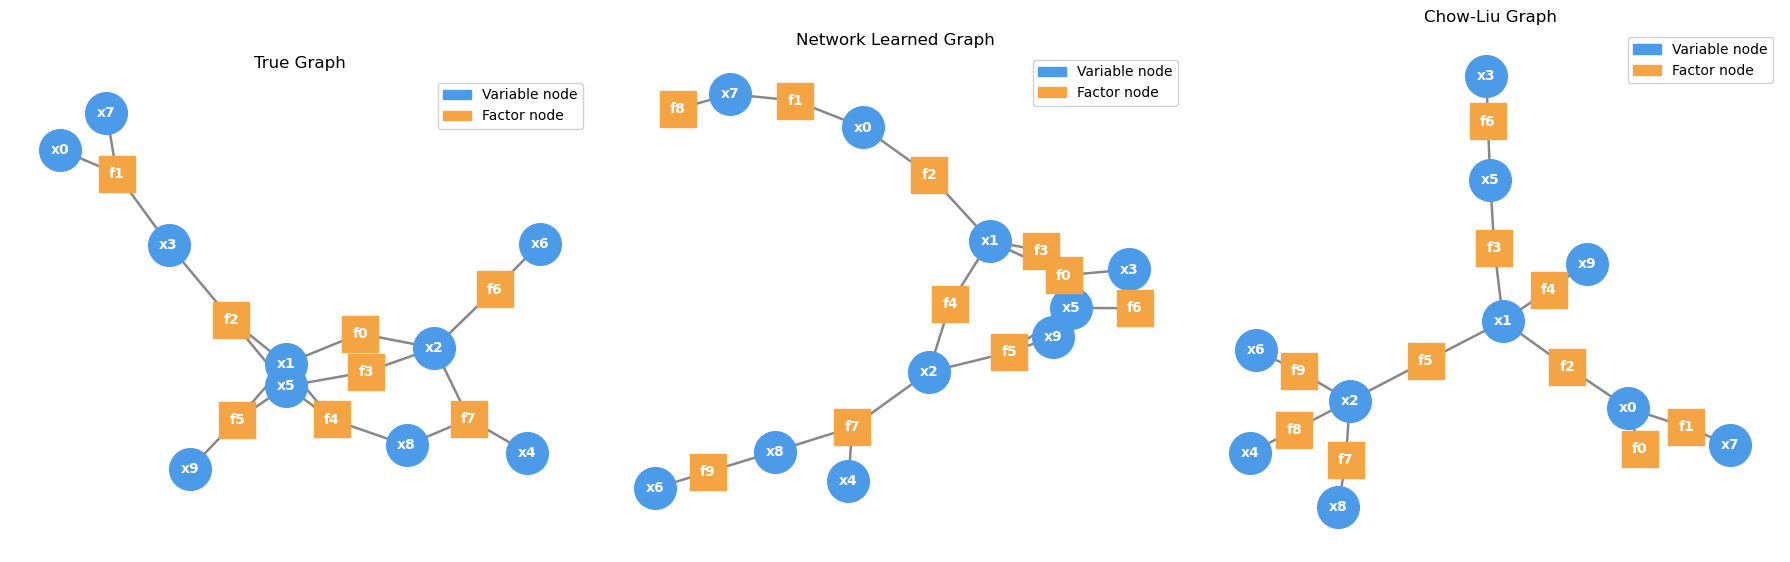

In [26]:
# TEMPORARY: JUST FOR STATUS UPDATE II

fig, axs = plt.subplots(1,3, figsize=(18,6))

random_graph.display_graph(seed=388, ax=axs[0])
learner_to_graph(best_lrn_graph).display_graph(seed=38, ax=axs[1])
chow_liu_graph.display_graph(seed=10, ax=axs[2])

axs[0].set_title("True Graph")
axs[1].set_title("Network Learned Graph")
axs[2].set_title("Chow-Liu Graph")

# plt.savefig("../img/graphs.png")
plt.show()

In [27]:
print(f"KL MLE: {kl_mle_optimal(random_graph, samples_graph):.4f}")
print(f"KL Network: {kl_divergence(random_graph, best_lrn_graph):.4f}")
print(f"KL Chow-Liu: {kl_divergence(random_graph, chow_liu_graph):.4f}")

KL MLE: 0.3732
KL Network: 0.1356
KL Chow-Liu: 0.1310


In [28]:
print(f"SHD Network: {structural_hamming_distance(random_graph, best_lrn_graph):.0f}")
print(f"SHD Chow-Liu: {structural_hamming_distance(random_graph, chow_liu_graph):.0f}")

SHD Network: 9
SHD Chow-Liu: 9


In [29]:
print(f"Density Graph: {graph_density(random_graph):.2f}")
print(f"Density Network: {graph_density(best_lrn_graph):.2f}")
print(f"Density Chow-Liu: {graph_density(chow_liu_graph):.2f}")

Density Graph: 1.78
Density Network: 1.67
Density Chow-Liu: 1.00


1) KL and SHD vs lambda_bp for loopy graph and tree
   - KL graph on left, SHD on right [or maybe 4 separate graphs - would make stuff with dotted lines simpler]
   - color by graph type (loopy vs tree)
   - Have dotted lines for MLE and Chow-Liu KL on KL graph, dotted lines for Chow-Liu SHD on SHD graph
2) Show graphs
   - True graph, recovered graph (optimal), and recovered graph (too much or too little or both)